In [1]:
import numpy
import matplotlib.pyplot as plt
import scipy
import pandas
import seaborn

print("All imports OK")
print(numpy.__file__)
print(plt.__file__)

All imports OK
/home/govind/.local/lib/python3.10/site-packages/numpy/__init__.py
/home/govind/.local/lib/python3.10/site-packages/matplotlib/pyplot.py


In [2]:
from neuron import h
h.load_file('stdrun.hoc')
import numpy as np
import matplotlib.pyplot as plt
from stellate import Stellate
h.celsius = 37.0
h.steps_per_ms = 40
h.dt = 0.025
h.cvode_active(0)



0.0

In [84]:
stellate_0 = Stellate(0)

stell_comb_ic = h.IClamp(stellate_0.soma(0.5))
stell_comb_ic.dur = 1e9

time_dur = 12000

time_steps = int(time_dur / h.dt)
time_arr = np.arange(0,time_dur,h.dt)

input_amp = -3.1e-3
theta_amp = 1e-4
theta_freq = 10.0

initial_phase = np.random.uniform(0, 2 * np.pi)
mean,std=0,1e-5

stell_v = h.Vector().record(stellate_0.soma(0.5)._ref_v)
stellate_gh_vec = h.Vector().record(stellate_0.soma(0.5).stellate_mech._ref_gh)
input_rec = h.Vector().record(stell_comb_ic._ref_amp)

nc_stell = h.NetCon(stellate_0.soma(0.5)._ref_v, None, sec=stellate_0.soma)
nc_stell.threshold = 0
spike_times_stell = h.Vector()
nc_stell.record(spike_times_stell)
time = h.Vector().record(h._ref_t)



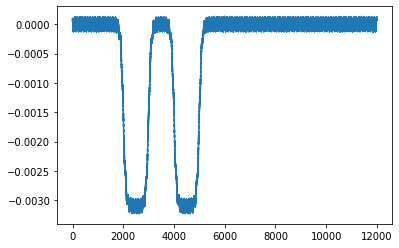

In [85]:
def input_func(t_ms):
    first_term = 0.5 * (np.tanh((t_ms - 2000)/100) - np.tanh((t_ms - 3000)/100))
    second_term = 0.5 * (np.tanh((t_ms - 4000)/100) - np.tanh((t_ms - 5000)/100))
    theta_term = theta_amp * np.sin(2 * np.pi * theta_freq * t_ms / 1000 + initial_phase)
    return (input_amp*(first_term + second_term)) + theta_term

noise_input = np.random.normal(0,std,time_steps)
stell_input = input_func(time_arr) + noise_input
plt.plot(time_arr,stell_input)
plt.show()

In [86]:
input_vec = h.Vector(stell_input)
input_vec.play(stell_comb_ic._ref_amp,h.dt)

h.finitialize(-65)
h.frecord_init()
h.continuerun(time_dur)



0.0

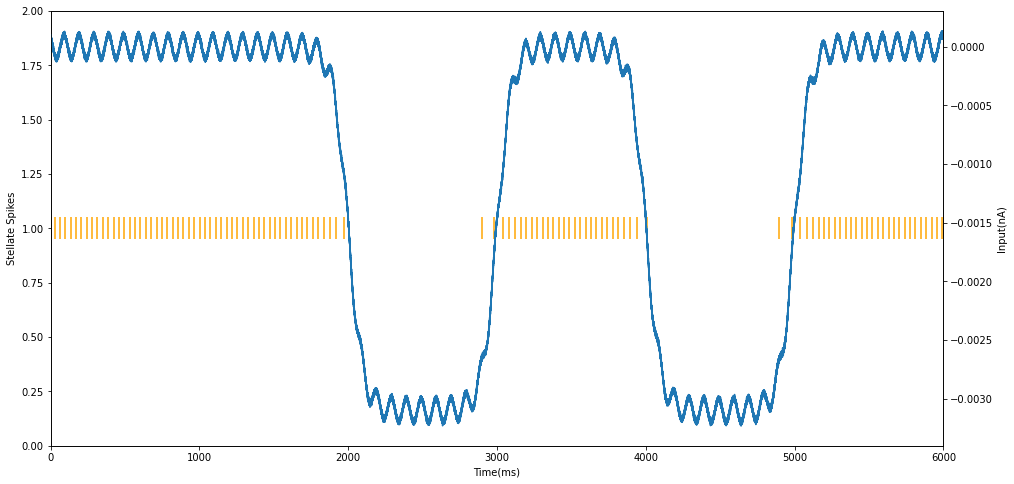

In [87]:
spike_times_array = np.array(spike_times_stell.to_python())
phases = (((spike_times_array) * theta_freq * 2 * np.pi / 1000)+initial_phase) % (2 * np.pi)

fig,ax = plt.subplots(figsize=(16,8))
ax1=ax.twinx()
ax.eventplot(spike_times_array,label="Stellate Spikes",color='orange',linelengths=0.1)
ax.set_ylim(0,2)
ax1.plot(time_arr,stell_input,label="Input")
ax.set_ylabel('Stellate Spikes')
ax1.set_ylabel('Input(nA)')
ax.set_xlabel('Time(ms)')
plt.xlim(0,6000)
plt.show()